In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Reading Data

In [ ]:
df = pd.read_csv('/content/Gaming and Mental Health.csv', encoding='latin1')
display(df.head())
df.info()

,record_id,age,gender,daily_gaming_hours,game_genre,primary_game,gaming_platform,sleep_hours,sleep_quality,sleep_disruption_frequency,...,continued_despite_problems,eye_strain,back_neck_pain,weight_change_kg,exercise_hours_weekly,social_isolation_score,face_to_face_social_hours_weekly,monthly_game_spending_usd,years_gaming,gaming_addiction_risk_level
0,GD0001,17,Male,11.1,Mobile Games,Clash of Clans,PC,3.7,Very Poor,Sometimes,...,True,True,False,6.8,3.7,7,1.3,383.70,3,Severe
1,GD0002,21,Male,3.0,MOBA,Dota 2,PC,7.2,Fair,Rarely,...,False,False,False,0.4,8.5,2,10.7,46.64,1,Low
2,GD0003,23,Male,7.6,FPS,CS:GO,Multi-platform,4.4,Fair,Often,...,True,False,True,1.8,7.1,5,3.2,100.81,6,Severe
3,GD0004,20,Female,7.2,RPG,Skyrim,Multi-platform,5.1,Fair,Often,...,False,True,True,0.2,5.2,4,9.1,51.60,7,High
4,GD0005,18,Male,6.8,Battle Royale,Apex Legends,PC,3.4,Poor,Never,...,False,False,False,0.5,6.1,4,4.5,32.57,1,Moderate


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 27 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   record_id                         1000 non-null   object 
 1   age                               1000 non-null   int64  
 2   gender                            1000 non-null   object 
 3   daily_gaming_hours                1000 non-null   float64
 4   game_genre                        1000 non-null   object 
 5   primary_game                      1000 non-null   object 
 6   gaming_platform                   1000 non-null   object 
 7   sleep_hours                       1000 non-null   float64
 8   sleep_quality                     1000 non-null   object 
 9   sleep_disruption_frequency        1000 non-null   object 
 10  academic_work_performance         1000 non-null   object 
 11  grades_gpa                        754 non-null    float64
 12  work_pr

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.drop('record_id', axis=1, inplace=True)

# 2. Exploratory Data Analysis (EDA)

In [ ]:
num_cols = df.select_dtypes(include='number').columns
cat_cols = df.select_dtypes(include='object').columns

In [ ]:
num_cols

Index(['age', 'daily_gaming_hours', 'sleep_hours', 'grades_gpa',
       'work_productivity_score', 'weight_change_kg', 'exercise_hours_weekly',
       'social_isolation_score', 'face_to_face_social_hours_weekly',
       'monthly_game_spending_usd', 'years_gaming'],
      dtype='object')

In [ ]:
cat_cols

Index(['gender', 'game_genre', 'primary_game', 'gaming_platform',
       'sleep_quality', 'sleep_disruption_frequency',
       'academic_work_performance', 'mood_state', 'mood_swing_frequency',
       'gaming_addiction_risk_level'],
      dtype='object')

## Check Inconsistent Value

In [ ]:
for col in cat_cols:
  print(df[col].value_counts())
  print('---'*10)

gender
Male      647
Female    331
Other      22
Name: count, dtype: int64
------------------------------
game_genre
MOBA             156
RPG              146
MMO              143
Battle Royale    141
Strategy         141
Mobile Games     139
FPS              134
Name: count, dtype: int64
------------------------------
primary_game
Dota 2                  57
Elden Ring              56
StarCraft II            55
World of Warcraft       52
Civilization VI         51
Mobile Legends          50
League of Legends       49
Final Fantasy XIV       47
Cyberpunk 2077          47
Elder Scrolls Online    44
Skyrim                  43
Fortnite                41
Clash of Clans          39
Warzone                 38
Genshin Impact          36
CS:GO                   36
PUBG Mobile             36
Call of Duty            35
Age of Empires          35
PUBG                    35
Valorant                33
Overwatch               30
Candy Crush             28
Apex Legends            27
Name: count, dtype

## Check Distribution

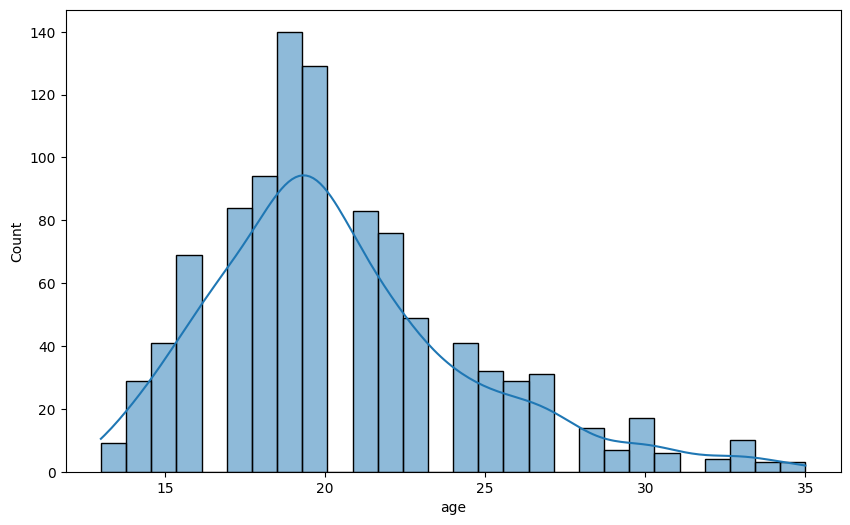

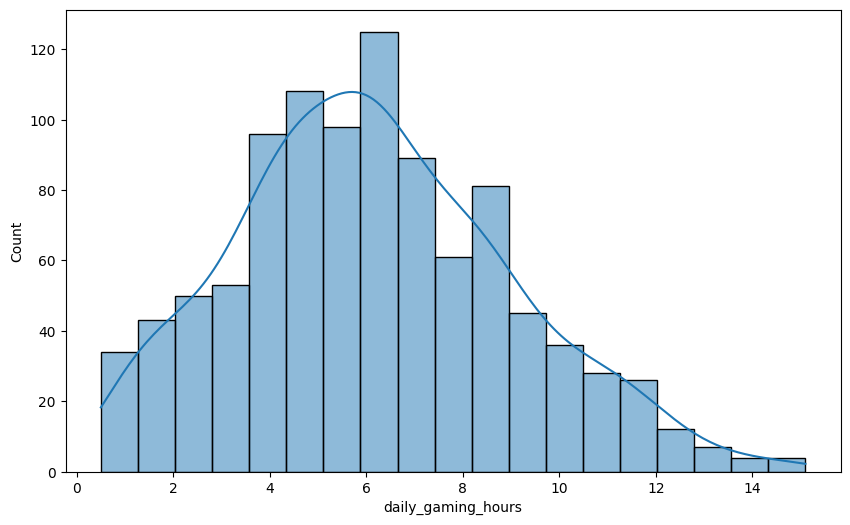

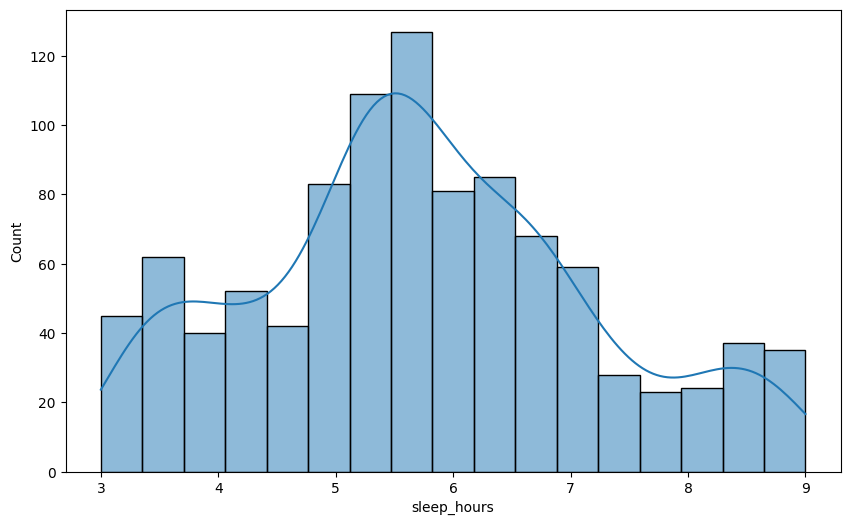

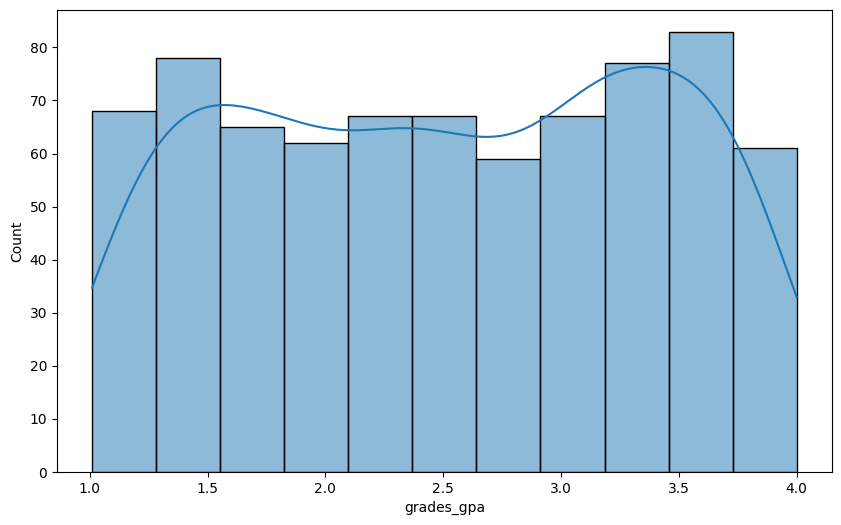

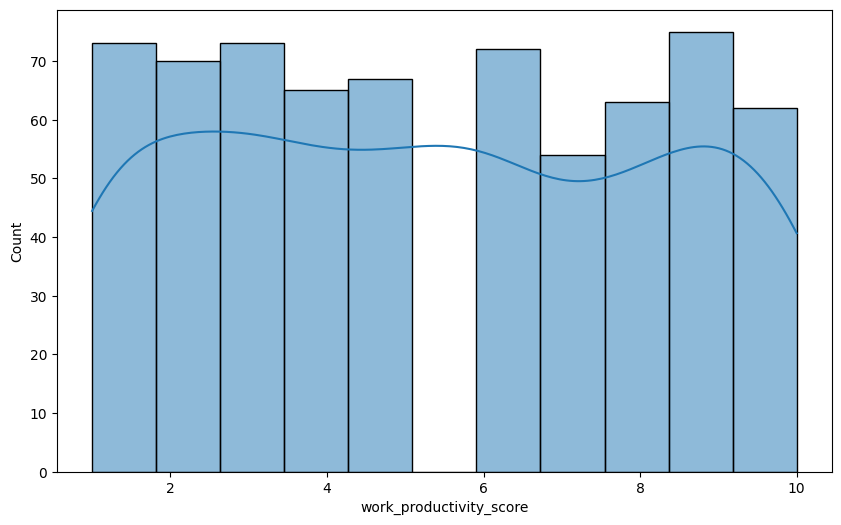

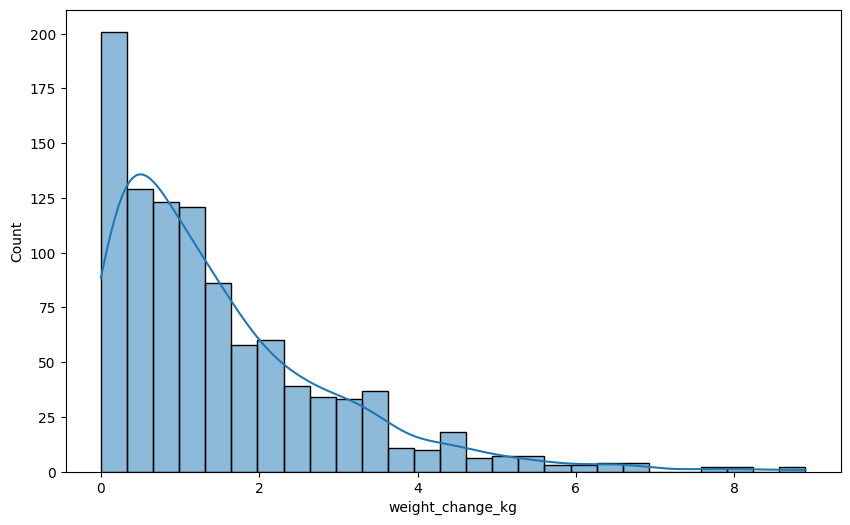

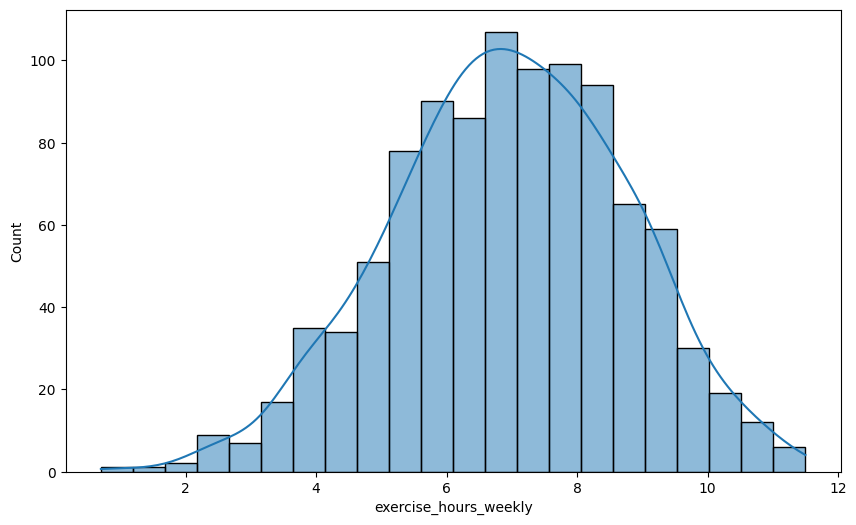

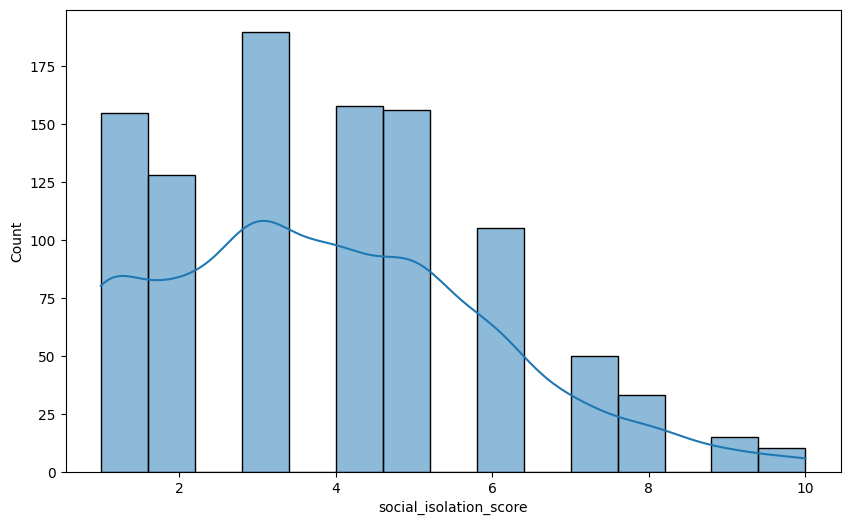

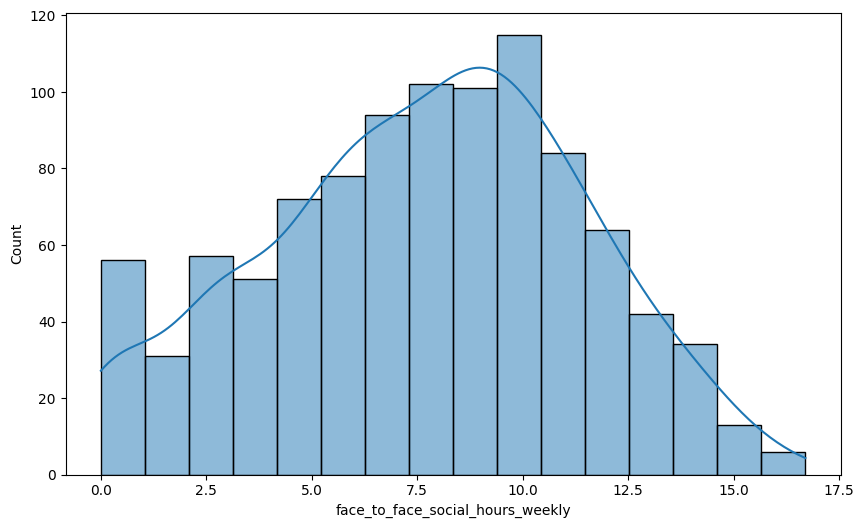

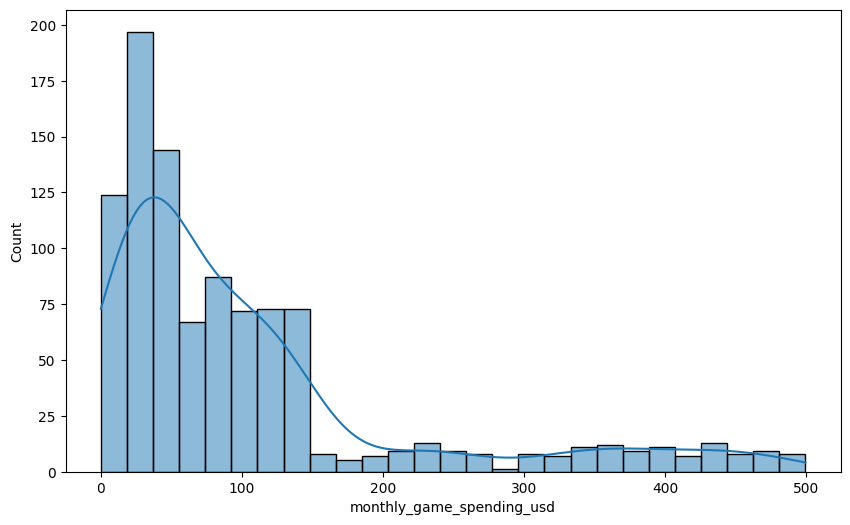

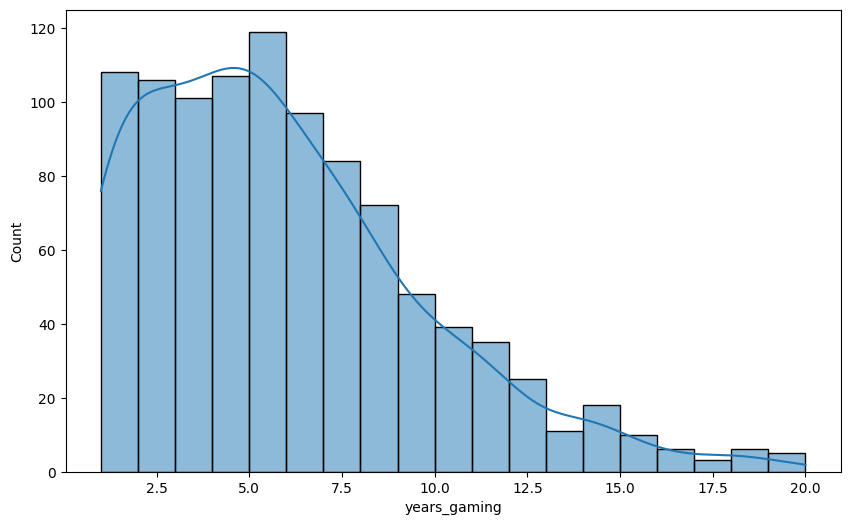

In [ ]:
for col in num_cols:
  plt.figure(figsize=(10, 6))
  sns.histplot(df[col], kde=True)
  plt.show()
  print(' ')

## Check Outlier

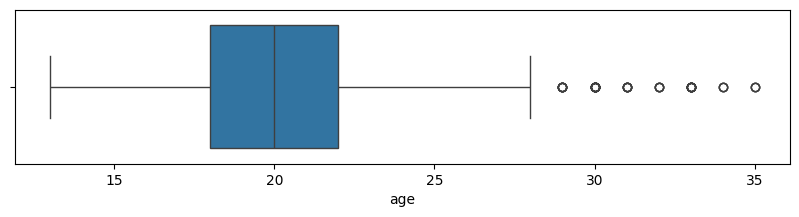

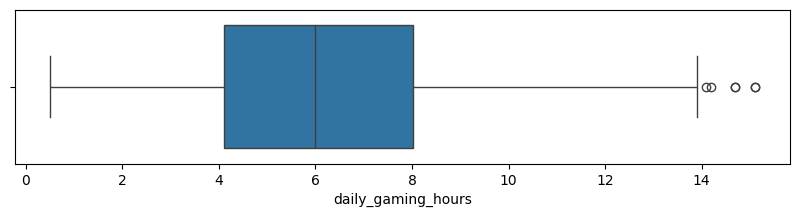

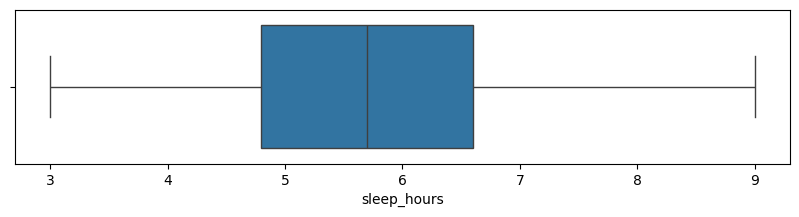

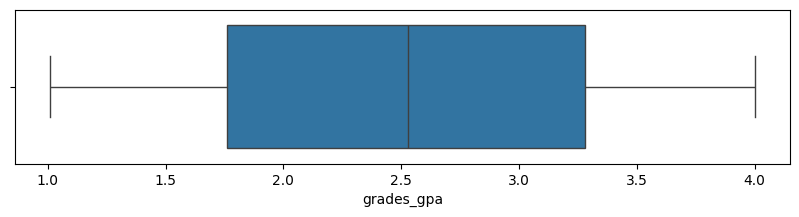

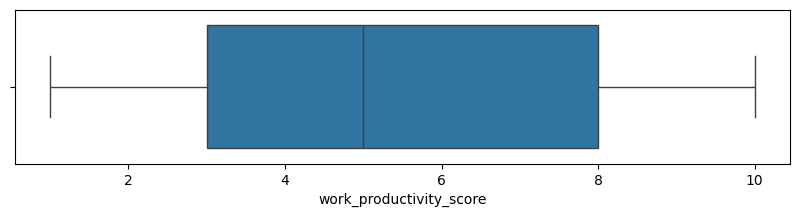

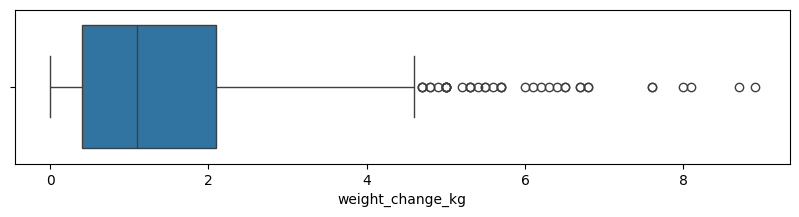

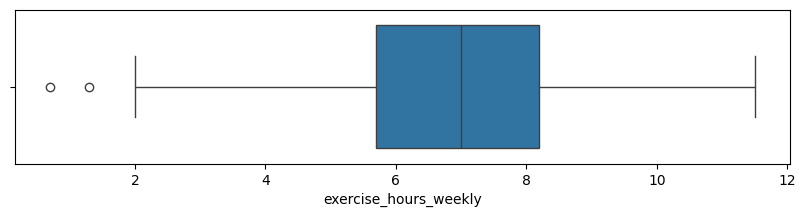

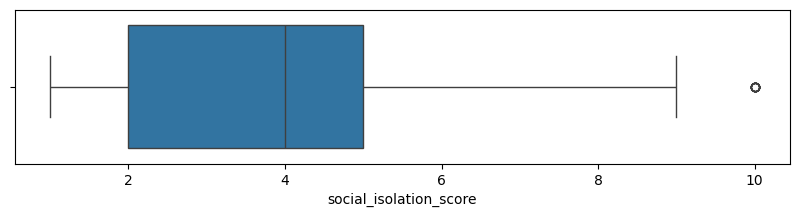

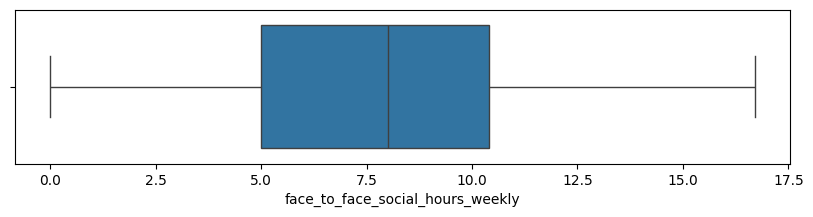

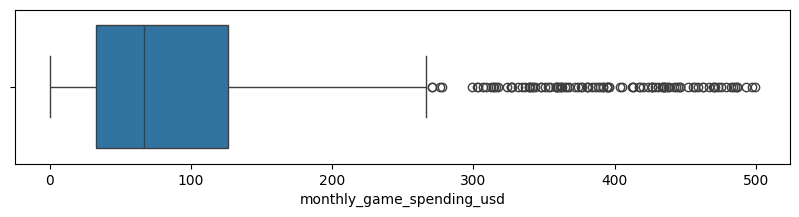

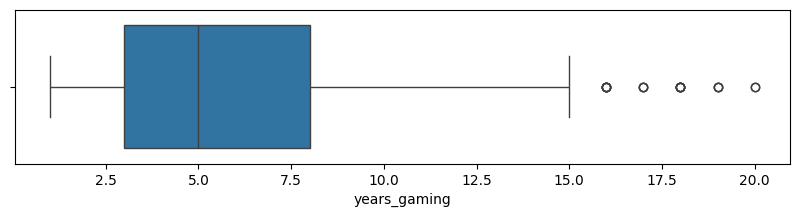

In [ ]:
for col in num_cols:
  plt.figure(figsize=(10, 2))
  sns.boxplot(df[col], orient='h')
  plt.show()
  print(' ')


--- Visualizing Relationship between Sleep Hours and Sleep Quality ---


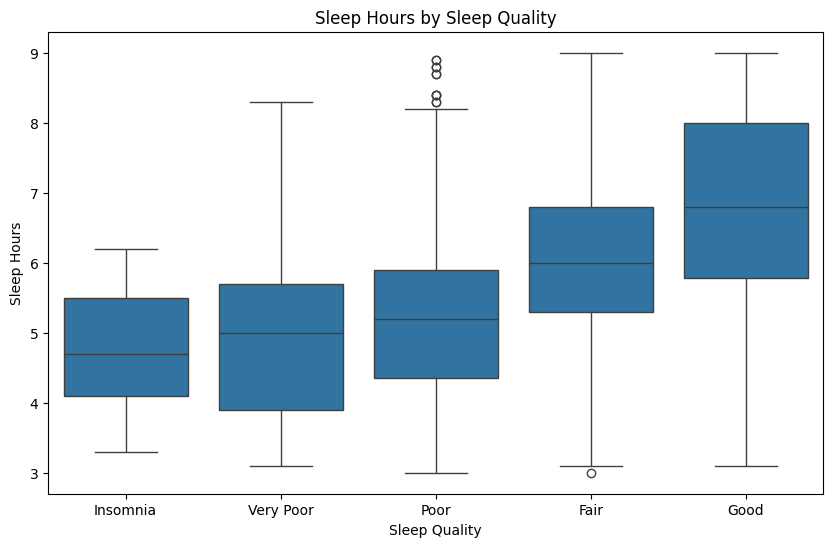


--- Visualizing Relationship between Sleep Hours and Sleep Disruption Frequency ---


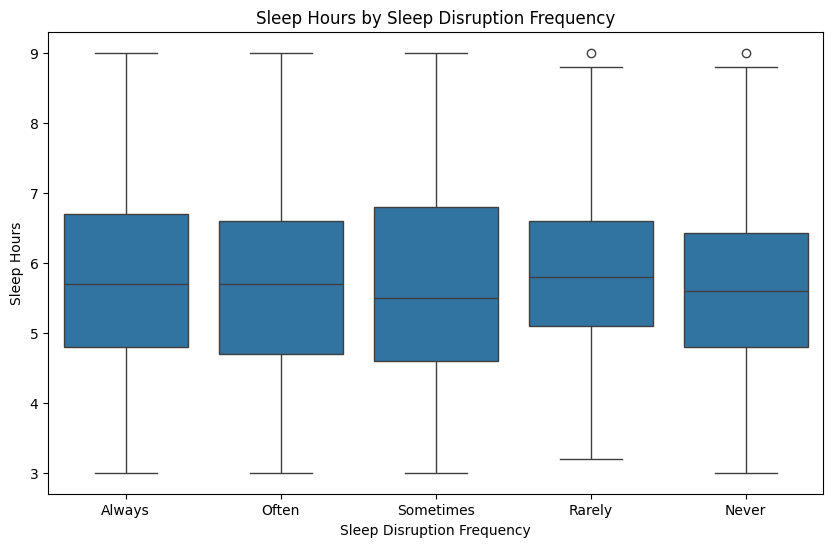


--- Count Plot for Sleep Quality vs. Sleep Disruption Frequency ---


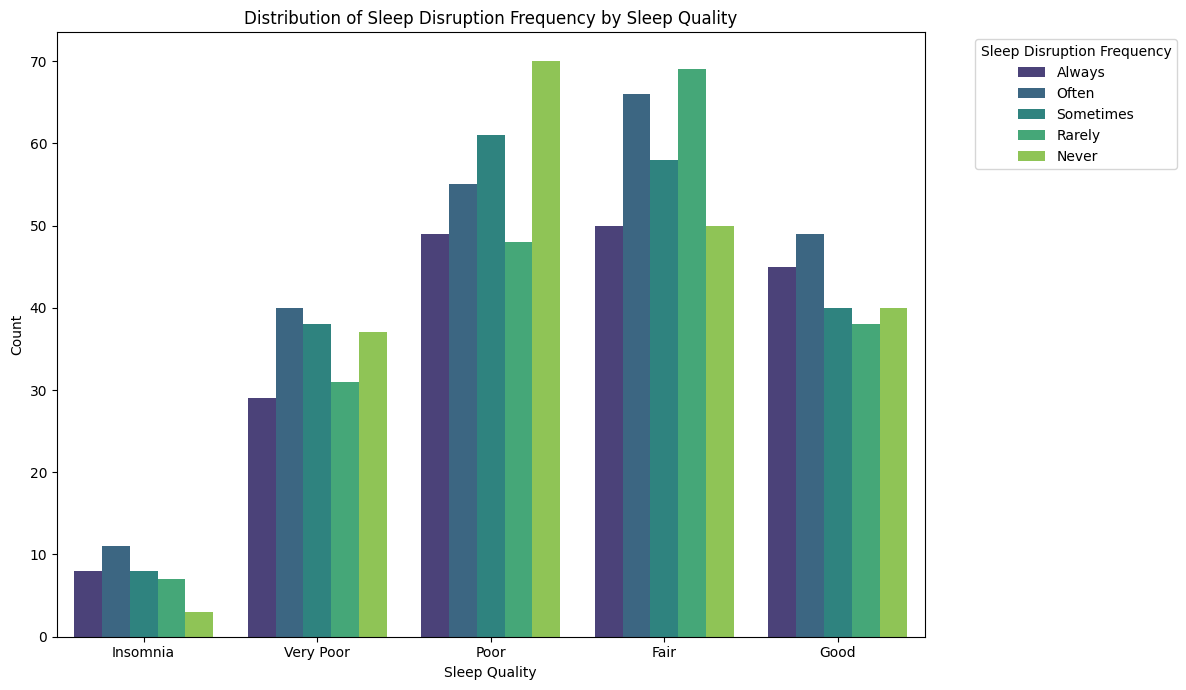

In [ ]:
sleep_quality_mapping = {
    'Insomnia': 0,
    'Very Poor': 1,
    'Poor': 2,
    'Fair': 3,
    'Good': 4
}

sleep_disruption_frequency_mapping = {
    'Always': 0,
    'Often': 1,
    'Sometimes': 2,
    'Rarely': 3,
    'Never': 4
}

df_sleep_analysis = df[['sleep_quality', 'sleep_hours', 'sleep_disruption_frequency']].copy()
df_sleep_analysis['sleep_quality_encoded'] = df_sleep_analysis['sleep_quality'].map(sleep_quality_mapping)
df_sleep_analysis['sleep_disruption_frequency_encoded'] = df_sleep_analysis['sleep_disruption_frequency'].map(sleep_disruption_frequency_mapping)

print("\n--- Visualizing Relationship between Sleep Hours and Sleep Quality ---")
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_sleep_analysis, x='sleep_quality', y='sleep_hours', order=list(sleep_quality_mapping.keys()))
plt.title('Sleep Hours by Sleep Quality')
plt.xlabel('Sleep Quality')
plt.ylabel('Sleep Hours')
plt.show()

print("\n--- Visualizing Relationship between Sleep Hours and Sleep Disruption Frequency ---")
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_sleep_analysis, x='sleep_disruption_frequency', y='sleep_hours', order=list(sleep_disruption_frequency_mapping.keys()))
plt.title('Sleep Hours by Sleep Disruption Frequency')
plt.xlabel('Sleep Disruption Frequency')
plt.ylabel('Sleep Hours')
plt.show()

print("\n--- Count Plot for Sleep Quality vs. Sleep Disruption Frequency ---")
plt.figure(figsize=(12, 7))
sns.countplot(data=df_sleep_analysis, x='sleep_quality', hue='sleep_disruption_frequency',
              order=list(sleep_quality_mapping.keys()),
              hue_order=list(sleep_disruption_frequency_mapping.keys()), palette='viridis')
plt.title('Distribution of Sleep Disruption Frequency by Sleep Quality')
plt.xlabel('Sleep Quality')
plt.ylabel('Count')
plt.legend(title='Sleep Disruption Frequency', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


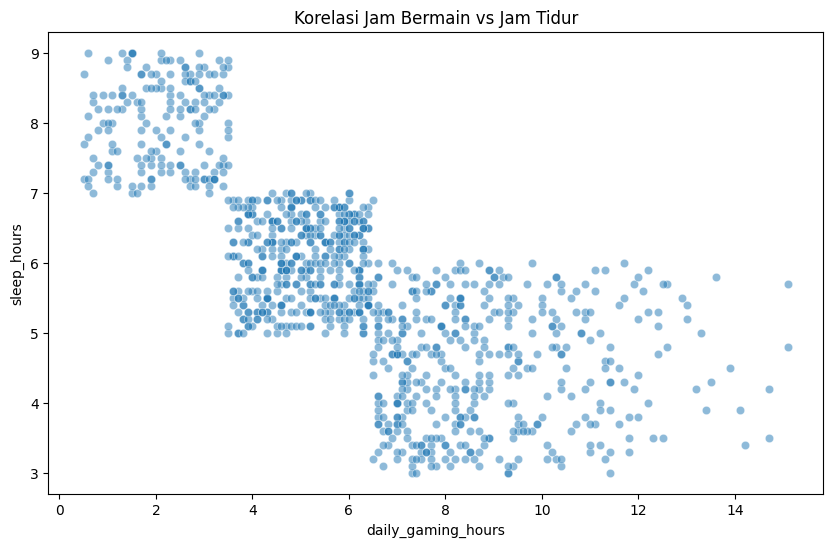

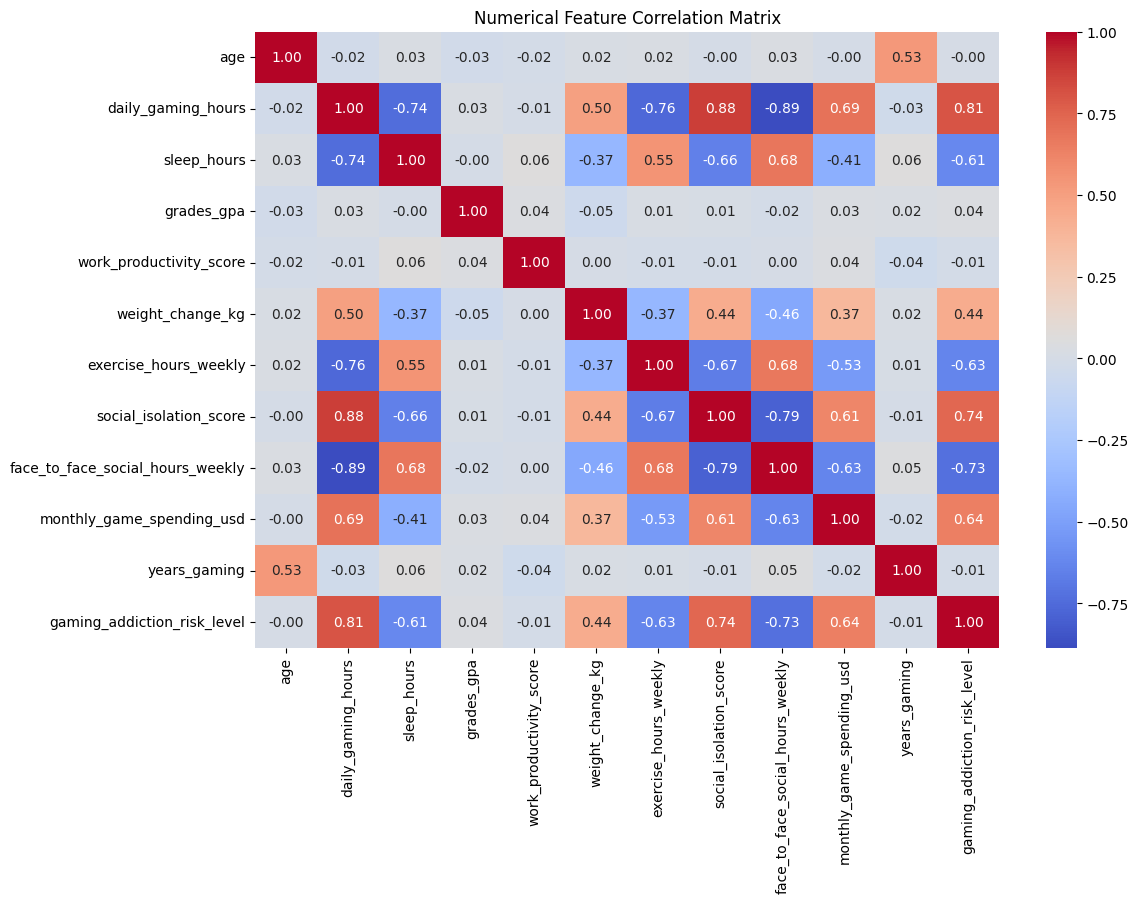

In [ ]:
risk_level_mapping = {
    'Low': 0,
    'Moderate': 1,
    'High': 2,
    'Severe': 3
}
df['gaming_addiction_risk_level'] = df['gaming_addiction_risk_level'].map(risk_level_mapping)

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='daily_gaming_hours', y='sleep_hours', alpha=0.5)
plt.title('Korelasi Jam Bermain vs Jam Tidur')
plt.show()

plt.figure(figsize=(12, 8))
numeric_cols = df.select_dtypes(include=[np.number]).columns
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Numerical Feature Correlation Matrix')
plt.show()

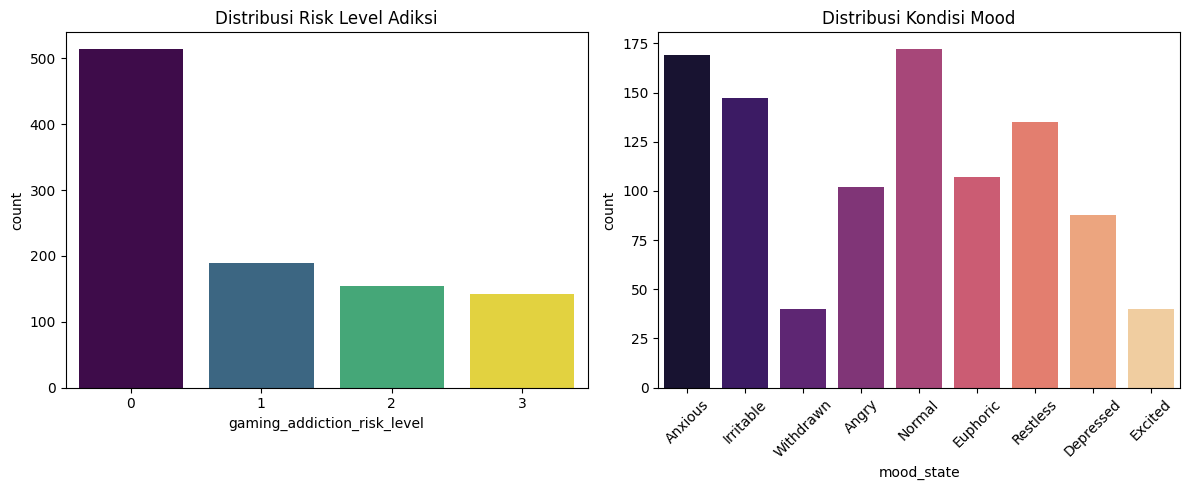

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.countplot(data=df, x='gaming_addiction_risk_level', hue='gaming_addiction_risk_level', palette='viridis', legend=False)
plt.title('Distribusi Risk Level Adiksi')

plt.subplot(1, 2, 2)
sns.countplot(data=df, x='mood_state', hue='mood_state', palette='magma', legend=False)
plt.xticks(rotation=45)
plt.title('Distribusi Kondisi Mood')

plt.tight_layout()
plt.show()

# 3. Preprocessing Data

## Handle Missing Value

In [ ]:
cols_missing_value = ['grades_gpa', 'work_productivity_score']

df.drop(cols_missing_value, axis=1, inplace=True)

print("Missing values setelah imputasi:")
print(df.isnull().sum())
print(f"\nUkuran data: {df.shape}")

Missing values setelah imputasi:
age                                 0
gender                              0
daily_gaming_hours                  0
game_genre                          0
primary_game                        0
gaming_platform                     0
sleep_hours                         0
sleep_quality                       0
sleep_disruption_frequency          0
academic_work_performance           0
mood_state                          0
mood_swing_frequency                0
withdrawal_symptoms                 0
loss_of_other_interests             0
continued_despite_problems          0
eye_strain                          0
back_neck_pain                      0
weight_change_kg                    0
exercise_hours_weekly               0
social_isolation_score              0
face_to_face_social_hours_weekly    0
monthly_game_spending_usd           0
years_gaming                        0
gaming_addiction_risk_level         0
dtype: int64

Ukuran data: (1000, 24)


## Remove Unnecessary Features

In [ ]:
df.drop(
    columns=[
        'primary_game',
        'gaming_platform',
        'social_isolation_score',
        'face_to_face_social_hours_weekly',
        'loss_of_other_interests'
    ],
    inplace=True
)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 19 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   age                          1000 non-null   int64  
 1   gender                       1000 non-null   object 
 2   daily_gaming_hours           1000 non-null   float64
 3   game_genre                   1000 non-null   object 
 4   sleep_hours                  1000 non-null   float64
 5   sleep_quality                1000 non-null   object 
 6   sleep_disruption_frequency   1000 non-null   object 
 7   academic_work_performance    1000 non-null   object 
 8   mood_state                   1000 non-null   object 
 9   mood_swing_frequency         1000 non-null   object 
 10  withdrawal_symptoms          1000 non-null   bool   
 11  continued_despite_problems   1000 non-null   bool   
 12  eye_strain                   1000 non-null   bool   
 13  back_neck_pain     

## Encoding

In [ ]:
from sklearn.preprocessing import OneHotEncoder

cat_cols = [
    'gender', 'game_genre', 'sleep_quality', 'sleep_disruption_frequency', 'academic_work_performance', 'mood_state', 'mood_swing_frequency'
]

ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

df_encoded = ohe.fit_transform(df[cat_cols])
df_ohe = pd.DataFrame(df_encoded, columns=ohe.get_feature_names_out(cat_cols), index=df.index)

df.drop(cat_cols, axis=1, inplace=True)

df_clean = pd.concat([df, df_ohe], axis=1)

print("Fitur baru hasil encoding telah ditambahkan.")

Fitur baru hasil encoding telah ditambahkan.


## Train Test Splitting

In [ ]:
from sklearn.model_selection import train_test_split

X = df_clean.drop('gaming_addiction_risk_level', axis=1)
y = df_clean['gaming_addiction_risk_level']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nShape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")
print(f"\nColumns in X: {X.columns.tolist()}")


Shape of X_train: (800, 51)
Shape of X_test: (200, 51)
Shape of y_train: (800,)
Shape of y_test: (200,)

Columns in X: ['age', 'daily_gaming_hours', 'sleep_hours', 'withdrawal_symptoms', 'continued_despite_problems', 'eye_strain', 'back_neck_pain', 'weight_change_kg', 'exercise_hours_weekly', 'monthly_game_spending_usd', 'years_gaming', 'gender_Female', 'gender_Male', 'gender_Other', 'game_genre_Battle Royale', 'game_genre_FPS', 'game_genre_MMO', 'game_genre_MOBA', 'game_genre_Mobile Games', 'game_genre_RPG', 'game_genre_Strategy', 'sleep_quality_Fair', 'sleep_quality_Good', 'sleep_quality_Insomnia', 'sleep_quality_Poor', 'sleep_quality_Very Poor', 'sleep_disruption_frequency_Always', 'sleep_disruption_frequency_Never', 'sleep_disruption_frequency_Often', 'sleep_disruption_frequency_Rarely', 'sleep_disruption_frequency_Sometimes', 'academic_work_performance_Average', 'academic_work_performance_Below Average', 'academic_work_performance_Excellent', 'academic_work_performance_Failing', 

# 4. Model Training and Evaluation

## XGBoost Classifier

In [ ]:
from xgboost import XGBClassifier
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

classes = np.unique(y_train)
class_weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
sample_weights = np.array([class_weights[label] for label in y_train])

xgb_model = XGBClassifier(objective='multi:softmax', num_class=len(y.unique()), eval_metric='mlogloss', use_label_encoder=False, random_state=42)

xgb_model.fit(X_train, y_train, sample_weight=sample_weights)

y_pred_xgb = xgb_model.predict(X_test)

print("XGBoost Classifier Evaluation:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_xgb, average='weighted'):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_xgb, average='weighted'):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_xgb, average='weighted'):.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb, digits=4))

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:04:46] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Classifier Evaluation:
Accuracy: 0.7550
Precision: 0.7570
Recall: 0.7550
F1-Score: 0.7558

Confusion Matrix:
[[92 11  0  0]
 [ 9 22  7  0]
 [ 0  6 16  9]
 [ 0  0  7 21]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9109    0.8932    0.9020       103
           1     0.5641    0.5789    0.5714        38
           2     0.5333    0.5161    0.5246        31
           3     0.7000    0.7500    0.7241        28

    accuracy                         0.7550       200
   macro avg     0.6771    0.6846    0.6805       200
weighted avg     0.7570    0.7550    0.7558       200



### Feature Importances for XGBoost Classifier

In [ ]:
feature_importances_xgb = pd.DataFrame({
    'feature': X_train.columns,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False)
display(feature_importances_xgb.head(10))


,feature,importance
1,daily_gaming_hours,0.146587
4,continued_despite_problems,0.061838
3,withdrawal_symptoms,0.057517
37,mood_state_Angry,0.041049
23,sleep_quality_Insomnia,0.038931
15,game_genre_FPS,0.031813
22,sleep_quality_Good,0.031324
43,mood_state_Normal,0.026771
13,gender_Other,0.026135
33,academic_work_performance_Excellent,0.026101


### Horizontal Bar Chart for XGBoost Feature Importances

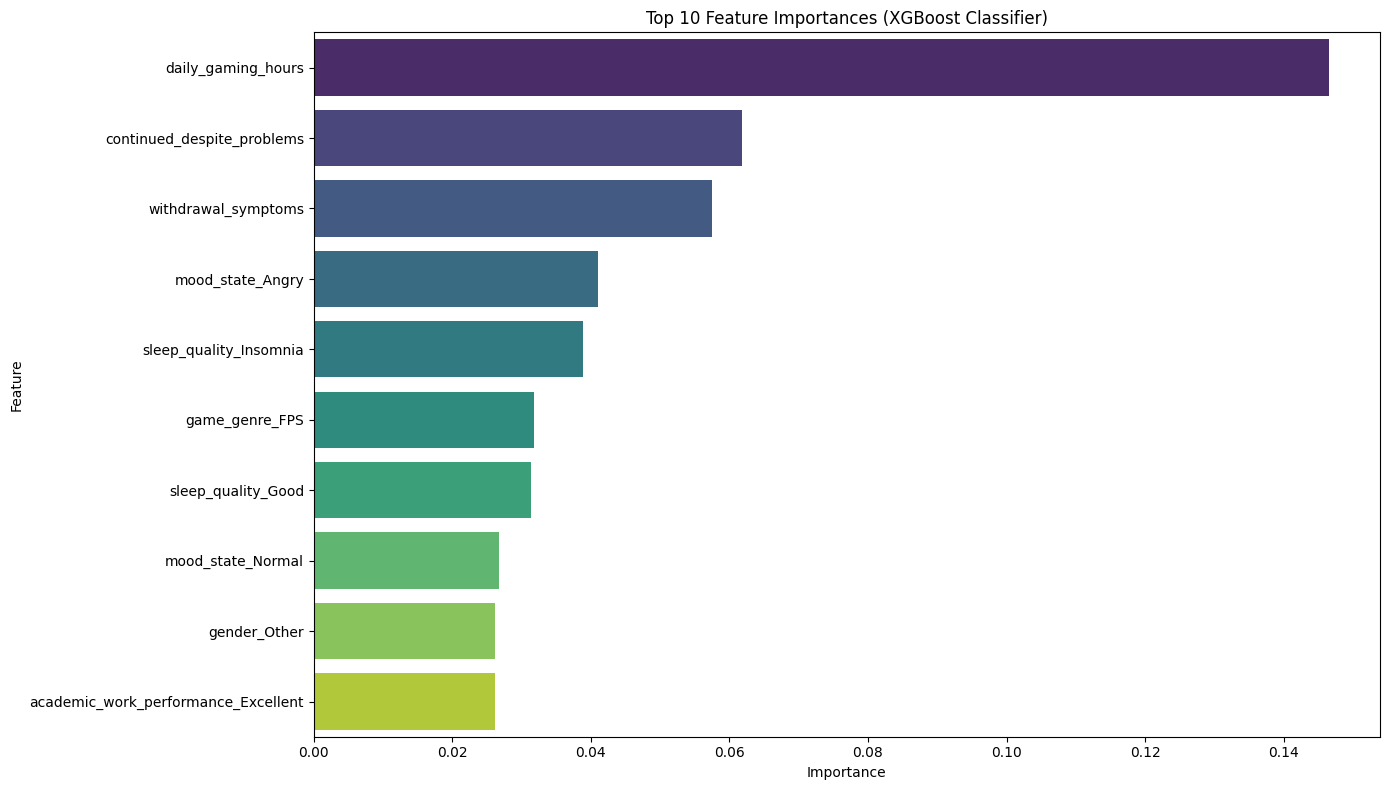

In [ ]:
plt.figure(figsize=(14, 8))
sns.barplot(x='importance', y='feature', hue='feature', data=feature_importances_xgb.head(10), palette='viridis', legend=False)
plt.title('Top 10 Feature Importances (XGBoost Classifier)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

## Support Vector Machine (SVM) Classifier

In [ ]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

svm_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(random_state=42, class_weight='balanced'))
])

svm_pipeline.fit(X_train, y_train)

y_pred_svm = svm_pipeline.predict(X_test)

print("SVM Classifier Evaluation:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_svm):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_svm, average='weighted'):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_svm, average='weighted'):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_svm, average='weighted'):.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_svm))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_svm, digits=4))

SVM Classifier Evaluation:
Accuracy: 0.7600
Precision: 0.7576
Recall: 0.7600
F1-Score: 0.7582

Confusion Matrix:
[[92 11  0  0]
 [11 19  7  1]
 [ 0  4 19  8]
 [ 0  0  6 22]]

Classification Report:
              precision    recall  f1-score   support

           0     0.8932    0.8932    0.8932       103
           1     0.5588    0.5000    0.5278        38
           2     0.5938    0.6129    0.6032        31
           3     0.7097    0.7857    0.7458        28

    accuracy                         0.7600       200
   macro avg     0.6889    0.6980    0.6925       200
weighted avg     0.7576    0.7600    0.7582       200



### Feature Importances for SVM Classifier (using Permutation Importance)

In [ ]:
from sklearn.inspection import permutation_importance

perm_importance_svm = permutation_importance(svm_pipeline, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1)

feature_importances_svm = pd.DataFrame({
    'feature': X_test.columns,
    'importance_mean': perm_importance_svm.importances_mean,
    'importance_std': perm_importance_svm.importances_std
}).sort_values('importance_mean', ascending=False)
display(feature_importances_svm.head(10))


,feature,importance_mean,importance_std
6,back_neck_pain,0.0810,0.019723
3,withdrawal_symptoms,0.0805,0.020180
1,daily_gaming_hours,0.0570,0.016155
4,continued_despite_problems,0.0460,0.013000
8,exercise_hours_weekly,0.0210,0.006633
9,monthly_game_spending_usd,0.0145,0.011500
46,mood_swing_frequency_Daily,0.0095,0.008500
0,age,0.0090,0.007000
12,gender_Male,0.0065,0.004500
11,gender_Female,0.0065,0.004500


### Horizontal Bar Chart for SVM Feature Importances (Permutation Importance)

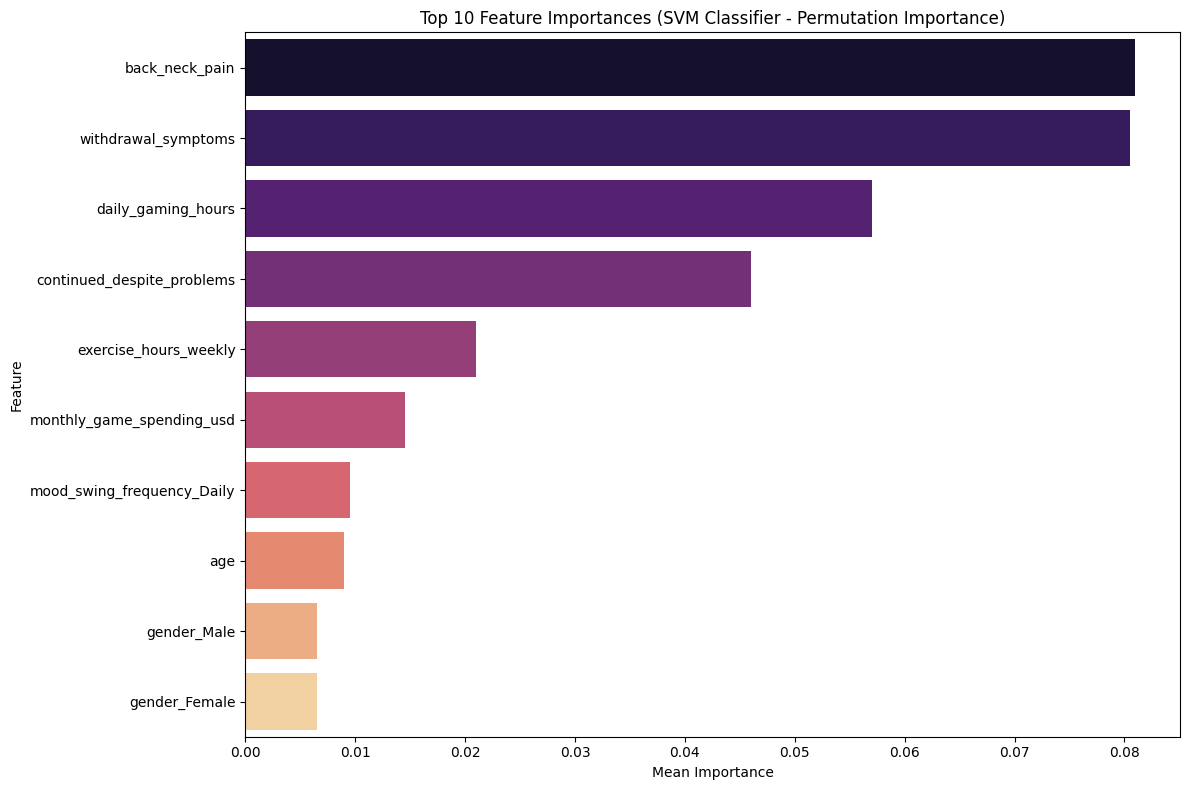

In [ ]:
plt.figure(figsize=(12, 8))
sns.barplot(x='importance_mean', y='feature', hue='feature', data=feature_importances_svm.head(10), palette='magma', legend=False)
plt.title('Top 10 Feature Importances (SVM Classifier - Permutation Importance)')
plt.xlabel('Mean Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

## Hyperparameter Tuning

In [ ]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

print("\n--- XGBoost Classifier Hyperparameter Tuning ---")

param_grid_xgb = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.05, 0.1, 0.2],
    'max_depth': [3, 5, 7]
}

xgb_model_tune = XGBClassifier(objective='multi:softmax', num_class=len(y.unique()), eval_metric='mlogloss', use_label_encoder=False, random_state=42)

grid_search_xgb = GridSearchCV(
    estimator=xgb_model_tune,
    param_grid=param_grid_xgb,
    scoring='f1_macro',
    cv=3,
    n_jobs=-1,
    verbose=1
)

fit_params_xgb = {"sample_weight": sample_weights}
grid_search_xgb.fit(X_train, y_train, **fit_params_xgb)

best_params_xgb = grid_search_xgb.best_params_
best_score_xgb = grid_search_xgb.best_score_

print(f"Best parameters for XGBoost: {best_params_xgb}")
print(f"Best F1-macro score for XGBoost: {best_score_xgb:.4f}")

y_pred_xgb_tuned = grid_search_xgb.best_estimator_.predict(X_test)

print("\nEvaluation of Tuned XGBoost Classifier:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb_tuned):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_xgb_tuned, average='macro'):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_xgb_tuned, average='macro'):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_xgb_tuned, average='macro'):.4f}")

print("\nConfusion Matrix (Tuned XGBoost):")
print(confusion_matrix(y_test, y_pred_xgb_tuned))

print("\nClassification Report (Tuned XGBoost):")
print(classification_report(y_test, y_pred_xgb_tuned, digits=4))


--- XGBoost Classifier Hyperparameter Tuning ---
Fitting 3 folds for each of 27 candidates, totalling 81 fits
Best parameters for XGBoost: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}
Best F1-macro score for XGBoost: 0.6837

Evaluation of Tuned XGBoost Classifier:
Accuracy: 0.7850
Precision: 0.7242
Recall: 0.7593
F1-Score: 0.7326

Confusion Matrix (Tuned XGBoost):
[[85 18  0  0]
 [ 0 32  6  0]
 [ 0  4 17 10]
 [ 0  0  5 23]]

Classification Report (Tuned XGBoost):
              precision    recall  f1-score   support

           0     1.0000    0.8252    0.9043       103
           1     0.5926    0.8421    0.6957        38
           2     0.6071    0.5484    0.5763        31
           3     0.6970    0.8214    0.7541        28

    accuracy                         0.7850       200
   macro avg     0.7242    0.7593    0.7326       200
weighted avg     0.8193    0.7850    0.7928       200



/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:05:20] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

print("\n--- SVM Classifier Hyperparameter Tuning ---")

param_grid_svm = {
    'svm__C': [0.1, 1, 10],
    'svm__gamma': ['scale', 'auto'],
    'svm__kernel': ['rbf', 'linear']
}

svm_pipeline_tune = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(random_state=42, class_weight='balanced'))
])

grid_search_svm = GridSearchCV(
    estimator=svm_pipeline_tune,
    param_grid=param_grid_svm,
    scoring='f1_macro',
    cv=3,
    n_jobs=-1,
    verbose=1
)

grid_search_svm.fit(X_train, y_train)

best_params_svm = grid_search_svm.best_params_
best_score_svm = grid_search_svm.best_score_

print(f"Best parameters for SVM: {best_params_svm}")
print(f"Best F1-macro score for SVM: {best_score_svm:.4f}")

y_pred_svm_tuned = grid_search_svm.best_estimator_.predict(X_test)

print("\nEvaluation of Tuned SVM Classifier:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_svm_tuned):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_svm_tuned, average='macro'):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_svm_tuned, average='macro'):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_svm_tuned, average='macro'):.4f}")

print("\nConfusion Matrix (Tuned SVM):")
print(confusion_matrix(y_test, y_pred_svm_tuned))

print("\nClassification Report (Tuned SVM):")
print(classification_report(y_test, y_pred_svm_tuned, digits=4))


--- SVM Classifier Hyperparameter Tuning ---
Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best parameters for SVM: {'svm__C': 1, 'svm__gamma': 'scale', 'svm__kernel': 'linear'}
Best F1-macro score for SVM: 0.6497

Evaluation of Tuned SVM Classifier:
Accuracy: 0.7750
Precision: 0.7176
Recall: 0.7292
F1-Score: 0.7218

Confusion Matrix (Tuned SVM):
[[90 13  0  0]
 [ 8 23  7  0]
 [ 0  6 18  7]
 [ 0  1  3 24]]

Classification Report (Tuned SVM):
              precision    recall  f1-score   support

           0     0.9184    0.8738    0.8955       103
           1     0.5349    0.6053    0.5679        38
           2     0.6429    0.5806    0.6102        31
           3     0.7742    0.8571    0.8136        28

    accuracy                         0.7750       200
   macro avg     0.7176    0.7292    0.7218       200
weighted avg     0.7826    0.7750    0.7776       200

